In [1]:
from __future__ import annotations
from pathlib import Path 

import yaml, json, os, sys

import numpy as np, matplotlib.pyplot as plt
import igraph as ig, networkx as nx
import torch

from collections import deque 
from matplotlib.ticker import MultipleLocator, FuncFormatter
import matplotlib.colors as mcolors


ROOT = "/scratch/sleonard/MoE_circuits"
sys.path.insert(0, ROOT)

with open(os.path.join(ROOT, "config.yaml")) as f:
    config = yaml.safe_load(f)

/scratch/sleonard/miniconda3/envs/megatron/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
MODELS   = ["olmoe", "deepseek-v2-lite", "mixtral-8x7b", "mixtral-8x22b", "qwen3-30b-a3b", "phi-3.5-moe", "qwen3-235b-a22b"]
DATASETS = ["c4", "math", "code"]

dags: dict[tuple[str, str], dict] = {}
for m in MODELS:
    for d in DATASETS:
        path = os.path.join(config["result_path"], f"circuits/dag_{m}_{d}.pt")
        dags[(m, d)] = torch.load(path, map_location="cpu")

In [3]:
from experiments.circuits.helper import get_thresholds, thresholding_routing_graph, show_enhanced_layered_graph

TARGET, Q = "AARV", 0.99
for m in MODELS:
    for d in DATASETS: 
        dag = dags[(m, d)]
        t = get_thresholds(dag, TARGET, [Q])[Q]
        g = thresholding_routing_graph(dag, TARGET, t)
        # show_enhanced_layered_graph(g, quantile=Q, target=TARGET, model=m, dataset=d, n_prompts=dag["n_prompts"])

In [ ]:
# --- Layer-pair mass (LPM) fingerprint with RANK-TRANSFORMED weights ---
# Cross-architecture scale issue: raw AARV magnitudes are bounded by
# (N_EXPERTS - 1), so a value of "2" in Mixtral (8 experts -> max 7) means a
# very different thing than in Qwen3-235B (128 experts -> max 127). Rank
# transform replaces each edge's |W| with its percentile rank in the model's
# own forward-edge distribution; afterward every model's edge values are
# uniform on (0, 1] regardless of architecture.
#
# Note: Dividing by (N_EXPERTS - 1) is a NO-OP because LPM normalizes bucket
# masses per-DAG; only the rank transform actually changes the analysis by
# removing distributional-shape differences (not just scale).
from experiments.circuits.helper import get_thresholds, layer_pair_mass, lpm_similarity
from scipy.stats import rankdata

WEIGHT, Q, N_BUCKETS = "AARV", 0.99, 12

def rank_transform(W):
    """Replace each forward-edge (s<r, |W|>0) entry's value with its percentile
    rank within the DAG's own distribution. Output values in (0, 1]."""
    W = W.cpu().numpy().astype(np.float64) if hasattr(W, "cpu") else np.asarray(W, dtype=np.float64)
    L = W.shape[0]
    s_idx = np.arange(L).reshape(-1, 1, 1, 1)
    r_idx = np.arange(L).reshape(1, 1, -1, 1)
    fwd = np.broadcast_to(s_idx < r_idx, W.shape)
    valid = fwd & (np.abs(W) > 1e-9)
    vals = np.abs(W[valid])
    if vals.size == 0:
        return np.zeros_like(W)
    ranks = rankdata(vals, method="average") / vals.size
    out = np.zeros_like(W)
    out[valid] = ranks
    return out

M_dict = {}
for key, dag in dags.items():
    W = rank_transform(dag[WEIGHT])
    # After rank transform, valid ranks are uniform on (0, 1].
    # Threshold at Q directly (the q-quantile of a uniform[(0,1]] is just q).
    Ws = np.where(W >= Q, W, 0.0)
    M_dict[key] = layer_pair_mass(Ws, n_buckets=N_BUCKETS)

# Grid: rows = models, cols = datasets.
fig, axes = plt.subplots(len(MODELS), len(DATASETS), figsize=(11, 3.5 * len(MODELS)))
vmax = max(M.max() for M in M_dict.values())
for i, m in enumerate(MODELS):
    for j, d in enumerate(DATASETS):
        ax = axes[i, j] if len(MODELS) > 1 else axes[j]
        im = ax.imshow(M_dict[(m, d)], cmap="viridis", origin="upper", vmin=0, vmax=vmax)
        ax.set_title(f"{m}/{d}", fontsize=10)
        ax.set_xlabel("receiver bucket (r/L)")
        ax.set_ylabel("sender bucket (s/L)")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle(f"LPM fingerprint (RANK-transformed {WEIGHT}, K={N_BUCKETS}, q={Q})")
plt.tight_layout(); plt.show()

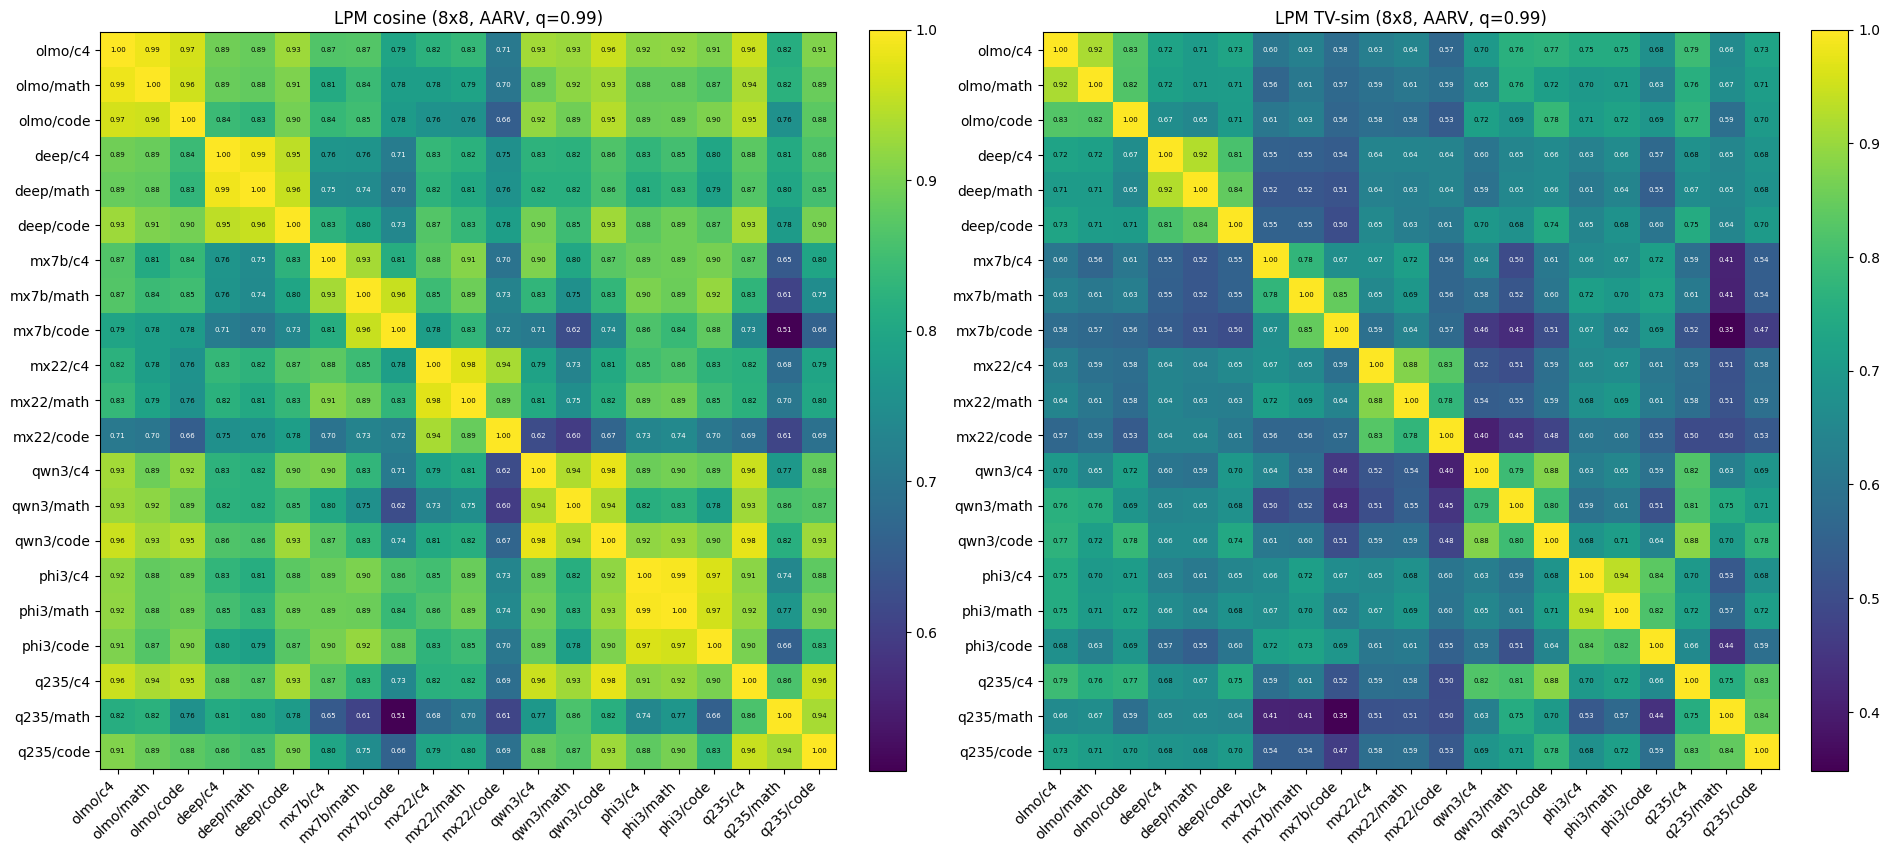

--- LPM cosine  (K=8, sparsified AARV, q=0.99) ---
  Within-model (task stability):
    WM[olmoe             ] = 0.974
    WM[deepseek-v2-lite  ] = 0.967
    WM[mixtral-8x7b      ] = 0.902
    WM[mixtral-8x22b     ] = 0.933
    WM[qwen3-30b-a3b     ] = 0.956
    WM[phi-3.5-moe       ] = 0.978
    WM[qwen3-235b-a22b   ] = 0.918
  Cross-model (CMS = same-dataset, CMD = different-dataset):
    olmoe              <-> deepseek-v2-lite    CMS=0.891  CMD=0.880
    olmoe              <-> mixtral-8x7b        CMS=0.829  CMD=0.823
    olmoe              <-> mixtral-8x22b       CMS=0.758  CMD=0.757
    olmoe              <-> qwen3-30b-a3b       CMS=0.931  CMD=0.920
    olmoe              <-> phi-3.5-moe         CMS=0.900  CMD=0.892
    olmoe              <-> qwen3-235b-a22b     CMS=0.886  CMD=0.875
    deepseek-v2-lite   <-> mixtral-8x7b        CMS=0.747  CMD=0.757
    deepseek-v2-lite   <-> mixtral-8x22b       CMS=0.808  CMD=0.811
    deepseek-v2-lite   <-> qwen3-30b-a3b       CMS=0.859  CMD=0.85

In [5]:
# --- 18x18 LPM similarity matrix + pairwise cross-model aggregates ---
# Restricted to softmax+L1-normalized routing architectures (consistent application
# of the score decomposition framework). DBRX and Llama 4 deferred.
keys = list(dags.keys())
n = len(keys)
LPM_COS = np.zeros((n, n))
LPM_TV  = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        LPM_COS[i, j] = lpm_similarity(M_dict[keys[i]], M_dict[keys[j]], metric="cosine")
        LPM_TV[i, j]  = lpm_similarity(M_dict[keys[i]], M_dict[keys[j]], metric="tv")

short = {
    "olmoe":            "olmo",
    "deepseek-v2-lite": "deep",
    "mixtral-8x7b":     "mx7b",
    "mixtral-8x22b":    "mx22",
    "qwen3-30b-a3b":    "qwn3",
    "phi-3.5-moe":      "phi3",
    "qwen3-235b-a22b":  "q235",
}
labels = [f"{short.get(k[0], k[0][:4])}/{k[1]}" for k in keys]

fig, axes = plt.subplots(1, 2, figsize=(19, 8.5))
for ax, (M, title) in zip(axes, [
    (LPM_COS, f"LPM cosine ({N_BUCKETS}x{N_BUCKETS}, {WEIGHT}, q={Q})"),
    (LPM_TV,  f"LPM TV-sim ({N_BUCKETS}x{N_BUCKETS}, {WEIGHT}, q={Q})"),
]):
    off_diag = M[~np.eye(n, dtype=bool)]
    vmin = float(off_diag.min())
    im = ax.imshow(M, cmap="viridis", vmin=vmin, vmax=1.0)
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(labels, rotation=45, ha="right"); ax.set_yticklabels(labels)
    mid = (vmin + 1.0) / 2
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center",
                    color="white" if M[i, j] < mid else "black", fontsize=5)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title)
plt.tight_layout(); plt.show()


# Block aggregates: within-model (task stability) + pairwise cross-model.
def block_mean(M, rows, cols, exclude_diag=False):
    vals = [M[i, j] for i in rows for j in cols if not (exclude_diag and i == j)]
    return float(np.mean(vals)) if vals else float("nan")

model_idx = {m: [i for i, k in enumerate(keys) if k[0] == m] for m in MODELS}

for name, M in [("LPM cosine", LPM_COS), ("LPM TV-sim", LPM_TV)]:
    print(f"--- {name}  (K={N_BUCKETS}, sparsified {WEIGHT}, q={Q}) ---")
    print("  Within-model (task stability):")
    for m in MODELS:
        wm = block_mean(M, model_idx[m], model_idx[m], exclude_diag=True)
        print(f"    WM[{m:<18s}] = {wm:.3f}")
    print("  Cross-model (CMS = same-dataset, CMD = different-dataset):")
    pairs = [(MODELS[a], MODELS[b]) for a in range(len(MODELS)) for b in range(a + 1, len(MODELS))]
    for m_a, m_b in pairs:
        idx_a, idx_b = model_idx[m_a], model_idx[m_b]
        CMS = float(np.mean([M[i, j] for i in idx_a for j in idx_b if keys[i][1] == keys[j][1]]))
        CMD = float(np.mean([M[i, j] for i in idx_a for j in idx_b if keys[i][1] != keys[j][1]]))
        print(f"    {m_a:<18s} <-> {m_b:<18s}  CMS={CMS:.3f}  CMD={CMD:.3f}")
    print()

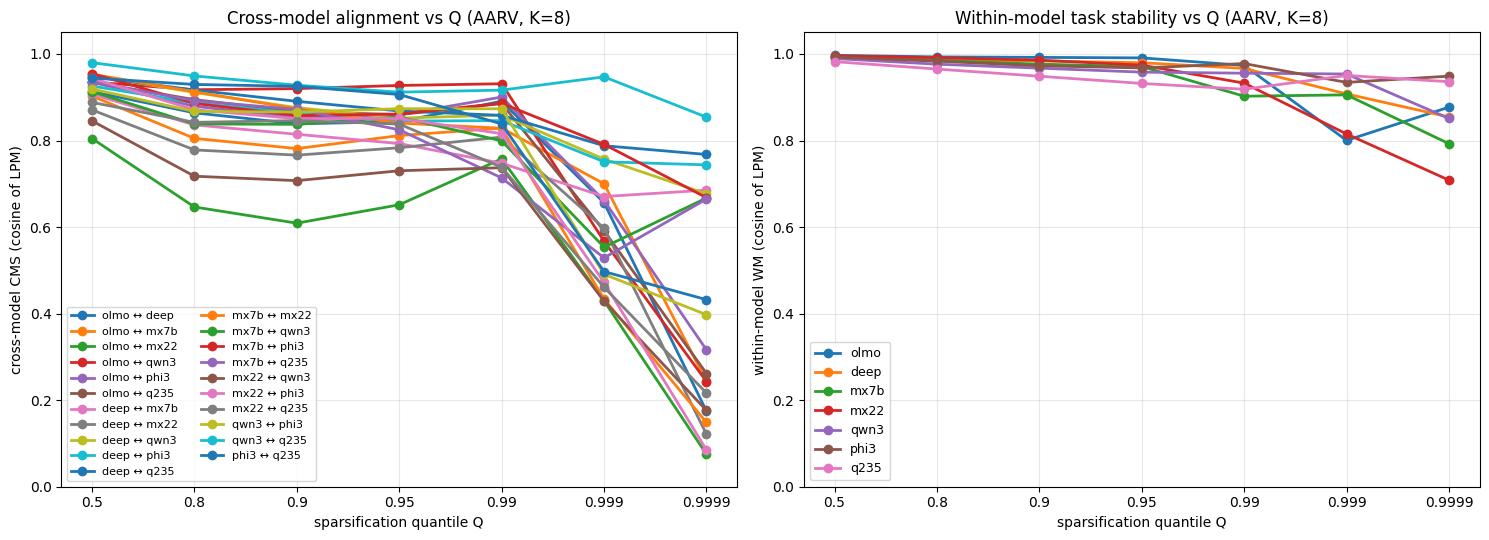

Q values:      0.5     0.8     0.9    0.95    0.99   0.999  0.9999

Cross-model CMS:
  olmo ↔ deep      0.913   0.864   0.839   0.844   0.891   0.656   0.175
  olmo ↔ mx7b      0.903   0.805   0.781   0.811   0.829   0.700   0.244
  olmo ↔ mx22      0.805   0.646   0.609   0.652   0.758   0.430   0.075
  olmo ↔ qwn3      0.935   0.917   0.920   0.927   0.931   0.567   0.243
  olmo ↔ phi3      0.935   0.879   0.853   0.859   0.900   0.661   0.316
  olmo ↔ q235      0.935   0.895   0.867   0.860   0.886   0.591   0.262
  deep ↔ mx7b      0.907   0.836   0.814   0.793   0.747   0.671   0.685
  deep ↔ mx22      0.871   0.778   0.766   0.783   0.808   0.597   0.121
  deep ↔ qwn3      0.951   0.911   0.876   0.852   0.859   0.757   0.677
  deep ↔ phi3      0.926   0.887   0.863   0.845   0.846   0.751   0.744
  deep ↔ q235      0.948   0.917   0.891   0.868   0.858   0.788   0.768
  mx7b ↔ mx22      0.953   0.913   0.873   0.840   0.828   0.434   0.149
  mx7b ↔ qwn3      0.913   0.838   0.83

In [6]:
# --- Sparsification sweep: how do cross-model alignment + task stability vary with Q? ---
# Diagnostic for metric robustness. If pair rankings reorder dramatically as Q varies,
# the LPM metric is unreliable as a similarity measure. If curves are roughly parallel
# across a wide Q range, that's the stable regime we should report.
Q_VALUES = [0.5, 0.8, 0.9, 0.95, 0.99, 0.999, 0.9999]

pair_keys = [(MODELS[a], MODELS[b]) for a in range(len(MODELS)) for b in range(a + 1, len(MODELS))]
CMS_curves = {p: [] for p in pair_keys}
CMD_curves = {p: [] for p in pair_keys}
WM_curves  = {m: [] for m in MODELS}

for Q_s in Q_VALUES:
    M_dict_s = {}
    for key, dag in dags.items():
        W = dag[WEIGHT]
        if isinstance(W, torch.Tensor):
            W = W.cpu().numpy().astype(np.float64)
        t = get_thresholds(dag, WEIGHT, [Q_s])[Q_s]
        Ws = np.where(np.abs(W) >= t, W, 0.0)
        M_dict_s[key] = layer_pair_mass(Ws, n_buckets=N_BUCKETS)
    SIM_s = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            SIM_s[i, j] = lpm_similarity(M_dict_s[keys[i]], M_dict_s[keys[j]], metric="cosine")
    for m in MODELS:
        WM_curves[m].append(block_mean(SIM_s, model_idx[m], model_idx[m], exclude_diag=True))
    for (m_a, m_b) in pair_keys:
        idx_a, idx_b = model_idx[m_a], model_idx[m_b]
        CMS_curves[(m_a, m_b)].append(
            float(np.mean([SIM_s[i, j] for i in idx_a for j in idx_b if keys[i][1] == keys[j][1]])))
        CMD_curves[(m_a, m_b)].append(
            float(np.mean([SIM_s[i, j] for i in idx_a for j in idx_b if keys[i][1] != keys[j][1]])))

# Plot 1: cross-model CMS as a function of Q (6 pairs).
# Plot 2: within-model WM as a function of Q (4 models).
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
x = np.arange(len(Q_VALUES))

short_pair = lambda p: f"{short[p[0]]} ↔ {short[p[1]]}"
ax = axes[0]
for p in pair_keys:
    ax.plot(x, CMS_curves[p], marker="o", linewidth=2, label=short_pair(p))
ax.set_xticks(x); ax.set_xticklabels([str(q) for q in Q_VALUES])
ax.set_xlabel("sparsification quantile Q")
ax.set_ylabel("cross-model CMS (cosine of LPM)")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8, ncol=2, loc="lower left")
ax.grid(alpha=0.3)
ax.set_title(f"Cross-model alignment vs Q ({WEIGHT}, K={N_BUCKETS})")

ax = axes[1]
for m in MODELS:
    ax.plot(x, WM_curves[m], marker="o", linewidth=2, label=short[m])
ax.set_xticks(x); ax.set_xticklabels([str(q) for q in Q_VALUES])
ax.set_xlabel("sparsification quantile Q")
ax.set_ylabel("within-model WM (cosine of LPM)")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_title(f"Within-model task stability vs Q ({WEIGHT}, K={N_BUCKETS})")

plt.tight_layout(); plt.show()

# Numeric output.
print(f"Q values:  {' '.join(f'{q:>7g}' for q in Q_VALUES)}")
print(f"\nCross-model CMS:")
for p in pair_keys:
    vals = " ".join(f"{v:>7.3f}" for v in CMS_curves[p])
    print(f"  {short_pair(p):<14s} {vals}")
print(f"\nCross-model CMS − CMD  (Platonic per-task signal; ~0 means no per-task alignment):")
for p in pair_keys:
    diffs = [c - d for c, d in zip(CMS_curves[p], CMD_curves[p])]
    vals = " ".join(f"{v:>+7.3f}" for v in diffs)
    print(f"  {short_pair(p):<14s} {vals}")
print(f"\nWithin-model WM:")
for m in MODELS:
    vals = " ".join(f"{v:>7.3f}" for v in WM_curves[m])
    print(f"  {short[m]:<6s}        {vals}")